## GEO Expression — `3_GEOexpression.txt`

~19,914 genes × 3,267 public GEO microarray/RNA-seq samples. Rows are genes (Ensembl IDs), columns are `GSM...` accessions. Values are raw expression (not log-transformed) — apply log before modelling. Map GSM samples to cell lines via `10_GEOInfo.txt`.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
%%time
df = pd.read_csv(f"{ini.df3}", sep="\t")

CPU times: total: 6.77 s
Wall time: 7.11 s


In [3]:
df.shape

(19914, 3268)

In [4]:
df.head()

,Gene,GSM101610,GSM101615,GSM101616,GSM101667,GSM101668,GSM101671,GSM101672,GSM101673,GSM101674,...,GSM960289,GSM960290,GSM960291,GSM960292,GSM960293,GSM960294,GSM960295,GSM960296,GSM960297,GSM960298
0,ENSG00000000003,33.615700,553.249756,540.452209,599.431152,625.242737,400.554657,412.995605,427.403900,461.123535,...,197.712616,387.427826,116.657890,104.889442,158.400604,736.519043,631.033142,791.054504,181.986893,353.206940
1,ENSG00000000005,40.925682,31.327406,33.934967,34.213123,32.466286,36.243233,37.952511,34.644428,34.225410,...,4.392303,4.230473,4.651096,5.175624,5.540960,4.211264,4.159354,4.480873,4.630062,4.296047
2,ENSG00000000419,2182.281250,3419.430420,3514.540039,2295.817383,2378.469727,2297.564697,2276.069092,2368.761475,2689.160156,...,936.201782,1162.099731,1249.029053,1354.346069,1159.747559,1561.643799,1547.089233,1551.400146,939.964661,1054.350952
3,ENSG00000000457,58.934814,95.068222,94.900459,51.810070,52.327530,50.011375,53.793667,51.172344,52.677490,...,35.778347,57.736485,25.528204,24.593216,23.337006,47.793488,41.268002,64.042831,37.363773,61.027988
4,ENSG00000000460,136.418900,257.929169,271.317230,162.090073,160.913849,206.788635,209.966019,134.272583,147.408554,...,14.693585,19.083935,114.056015,137.948593,149.641708,111.793892,98.536613,167.151016,12.268769,24.296593


### Basic structure
Genes are rows; GEO sample accessions are columns. The `Gene` column holds Ensembl IDs.

In [5]:
gene_col = "Gene"
sample_cols = [c for c in df.columns if c.startswith("GSM")]
print(f"Genes   : {len(df)}")
print(f"Samples : {len(sample_cols)}")
print(f"Value range: {df[sample_cols].min().min():.1f} – {df[sample_cols].max().max():.1f}")


Genes   : 19914
Samples : 3267


Value range: 1.2 – 49877.6


### Distribution before and after log transform
Raw microarray/RNA-seq values are right-skewed. A log1p transform makes the distribution more symmetric and comparable across samples.

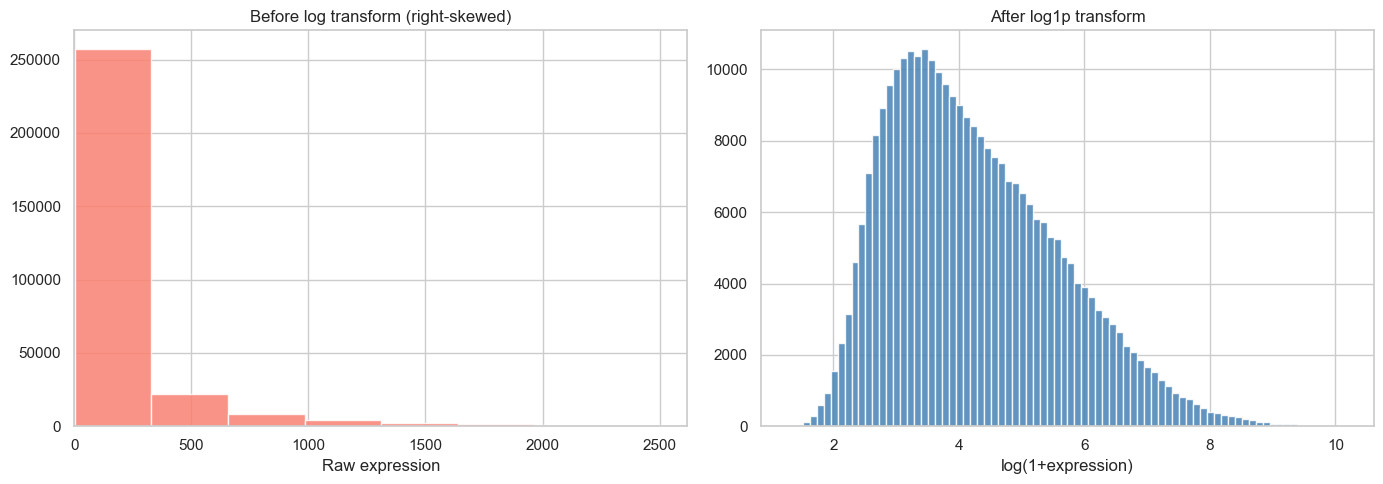

In [6]:
np.random.seed(42)
flat = df[sample_cols].values.flatten()
flat = flat[~np.isnan(flat)]
if len(flat) > 300_000:
    flat = np.random.choice(flat, 300_000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(flat, bins=80, color="salmon", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Raw expression"); axes[0].set_title("Before log transform (right-skewed)")
axes[0].set_xlim(0, np.percentile(flat, 99))

axes[1].hist(np.log1p(flat), bins=80, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("log(1+expression)"); axes[1].set_title("After log1p transform")

plt.tight_layout(); plt.show()


### Gene coverage overlap with DepMap RNA (df2)
Showing how many genes are shared between GEO and DepMap — important for cross-platform integration.

In [7]:
df2_tmp = pd.read_csv(ini.df2, nrows=1)
import re
df2_genes = set(re.search(r"(ENSG\d+)", c).group(1)
                for c in df2_tmp.columns if re.search(r"(ENSG\d+)", c))
geo_genes = set(df[gene_col])
overlap = geo_genes & df2_genes
print(f"GEO genes      : {len(geo_genes)}")
print(f"DepMap genes   : {len(df2_genes)}")
print(f"Shared genes   : {len(overlap)}  ({len(overlap)/len(geo_genes)*100:.1f}% of GEO)")


GEO genes      : 19914
DepMap genes   : 53961
Shared genes   : 19894  (99.9% of GEO)


### Top 20 most variable genes across GEO samples
Highly variable genes are the most informative for distinguishing cancer types.

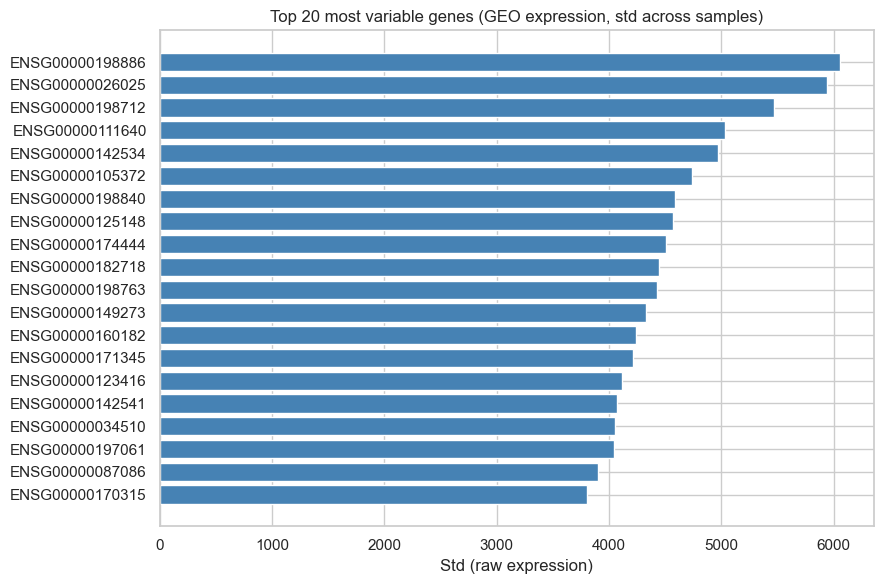

In [8]:
gene_std = df.set_index(gene_col)[sample_cols].std(axis=1).sort_values(ascending=False)
top20_var = gene_std.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20_var.index[::-1], top20_var.values[::-1], color="steelblue")
ax.set_title("Top 20 most variable genes (GEO expression, std across samples)")
ax.set_xlabel("Std (raw expression)")
plt.tight_layout(); plt.show()


### PCA of GEO samples (log-transformed)
Each dot is one GEO microarray sample. Tight clusters suggest similar cell lines.

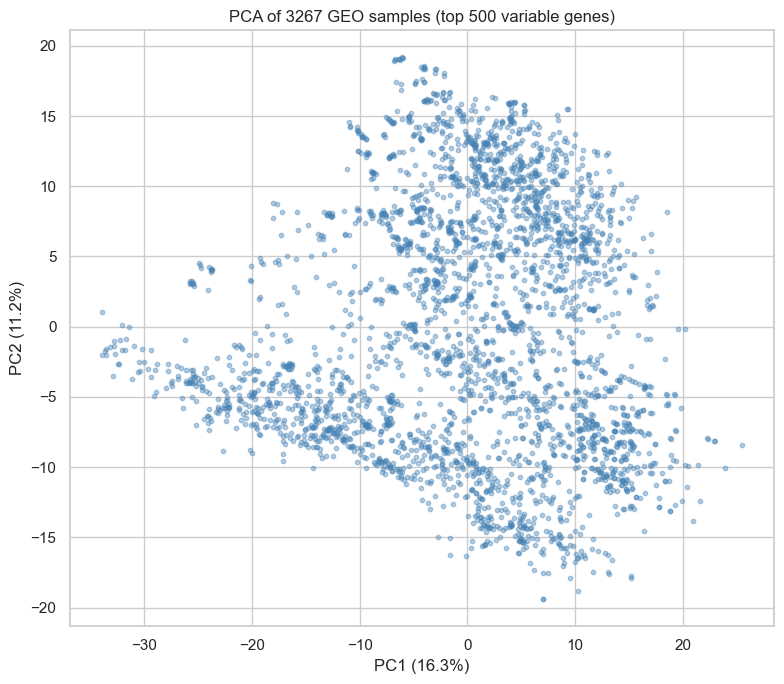

In [9]:
top500 = gene_std.head(500).index
X_geo = np.log1p(df.set_index(gene_col).loc[top500, sample_cols].T.values)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_geo)
var_exp = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.4, s=10, color="steelblue")
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)")
ax.set_title(f"PCA of {len(sample_cols)} GEO samples (top 500 variable genes)")
plt.tight_layout(); plt.show()


### Key findings

In [10]:
print("=== GEO Expression ===")
print(f"Genes           : {len(geo_genes)}")
print(f"Samples (GSM)   : {len(sample_cols)}")
print(f"Overlap w/ df2  : {len(overlap)} ({len(overlap)/len(geo_genes)*100:.1f}% of GEO genes)")
print(f"PCA PC1+PC2     : {sum(pca.explained_variance_ratio_)*100:.1f}% variance")


=== GEO Expression ===
Genes           : 19914
Samples (GSM)   : 3267
Overlap w/ df2  : 19894 (99.9% of GEO genes)
PCA PC1+PC2     : 27.5% variance


## Join Analysis — how this table connects to the others

df3 uses **GEO sample accessions** (`GSM...`) as column headers. It cannot be joined
directly to any DepMap file — it requires a three-hop path through df10 and df7.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df3 | column headers (`GSM...`) | df10 | `Geo_accession` | 1:1 | metadata bridge |
| df10 | `Cellosaurus_ID` | df7 | `Accession (CVCL_xxxx)` | 1:1 | name normalisation |
| df7 | `Accession` = RRID | df9 | `RRID` | 1:1 | → DepMap world |

**Why this matters:** GEO data expands cell line coverage significantly but at the cost
of a lossy three-hop join. Many GEO samples are unmatched at every step. Quantifying
the loss at each hop is critical before investing preprocessing effort in this layer.


In [11]:
# ── A/B: Join coverage df3 → df10 → df7 → df9 ──────────────────────────────
# Only read column names from df3 (fast — no data loaded)
geo_cols    = pd.read_csv(ini.df3, sep="\t", nrows=0).columns
gsm_cols    = set(c for c in geo_cols if c.startswith("GSM"))

df10_ids    = pd.read_csv(ini.df10, sep="\t",
                           usecols=["Geo_accession", "Cellosaurus_ID", "Cellline"])
df7_ids     = pd.read_csv(ini.df7,  usecols=["Accession (CVCL_xxxx)"])
df9_ids     = pd.read_csv(ini.df9,  usecols=["DepMap_ID", "RRID", "lineage"])

# Hop 1
df10_gsm    = set(df10_ids["Geo_accession"].dropna())
step1_match = gsm_cols & df10_gsm
step1_lost  = gsm_cols - df10_gsm

# Hop 2
df10_matched    = df10_ids[df10_ids["Geo_accession"].isin(step1_match)]
cvcl_from_df10  = set(df10_matched["Cellosaurus_ID"].dropna())
df7_cvcl        = set(df7_ids["Accession (CVCL_xxxx)"].dropna())
step2_match     = cvcl_from_df10 & df7_cvcl
step2_lost      = cvcl_from_df10 - df7_cvcl

# Hop 3
df9_rrid    = set(df9_ids["RRID"].dropna())
step3_match = step2_match & df9_rrid
step3_lost  = step2_match - df9_rrid

print("=== df3 join path: GSM columns → df10 → df7 → df9 ===")
print(f"GSM columns in df3          : {len(gsm_cols)}")
print(f"Hop 1 matched in df10       : {len(step1_match)} ({len(step1_match)/len(gsm_cols)*100:.1f}%)")
print(f"      lost at Hop 1         : {len(step1_lost)}")
print(f"Hop 2 CVCL_ matched in df7  : {len(step2_match)} ({len(step2_match)/max(len(cvcl_from_df10),1)*100:.1f}%)")
print(f"      lost at Hop 2         : {len(step2_lost)}")
print(f"Hop 3 reach df9 (RRID)      : {len(step3_match)} ({len(step3_match)/max(len(step2_match),1)*100:.1f}%)")
print(f"      lost at Hop 3         : {len(step3_lost)}")
print(f"\nOverall: {len(gsm_cols)} GEO samples → {len(step3_match)} usable cell lines in df9")
print(f"Survival rate: {len(step3_match)/len(gsm_cols)*100:.1f}%")

# Unique cell lines after full join
df10_linked = df10_ids[df10_ids["Cellosaurus_ID"].isin(step3_match)]
unique_cl = df10_linked["Cellline"].dropna().nunique()
print(f"Unique cell lines (Cellline col) reachable: {unique_cl}")


=== df3 join path: GSM columns → df10 → df7 → df9 ===
GSM columns in df3          : 3267
Hop 1 matched in df10       : 3267 (100.0%)
      lost at Hop 1         : 0
Hop 2 CVCL_ matched in df7  : 797 (100.0%)
      lost at Hop 2         : 0
Hop 3 reach df9 (RRID)      : 588 (73.8%)
      lost at Hop 3         : 209

Overall: 3267 GEO samples → 588 usable cell lines in df9
Survival rate: 18.0%
Unique cell lines (Cellline col) reachable: 674


In [12]:
# ── C: Format check on GSM column headers ───────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


gsm_series = pd.Series(sorted(gsm_cols))
fmt_check(gsm_series, "GSM column headers (df3)", prefix="GSM")
print()
# Cellosaurus_ID format in df10
fmt_check(df10_ids["Cellosaurus_ID"].dropna(), "Cellosaurus_ID (df10)", prefix="CVCL_")


Format check — GSM column headers (df3) (n=3267 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'GSM'  : True
  Length range        : 9 – 10
  Duplicates          : 0

Format check — Cellosaurus_ID (df10) (n=3159 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 2362


### Biological implications

The multi-hop join through df10 and df7 is inherently lossy. The largest loss is
typically at Hop 1 (GEO samples not in df10) because df10 was built by matching
a specific subset of GEO samples to Cellosaurus. GEO samples without a Cellosaurus
match simply cannot be attributed to a known cell line — they represent either
patient biopsies, primary cells, or cell lines not yet in Cellosaurus.

The practical question: is the surviving subset of GEO samples large enough and
diverse enough to justify the preprocessing effort? If the surviving set heavily
overlaps with df2 (DepMap RNA), GEO adds little new coverage.


In [13]:
# Biological: do surviving GEO cell lines overlap with df2?
df8_rna   = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])
df8_rna   = df8_rna[df8_rna["Datatype"] == "rna"]
df9_full  = pd.read_csv(ini.df9, usecols=["DepMap_ID", "RRID", "lineage"])

# df9 ModelIDs reachable from df3
geo_df9_models = set(df9_full[df9_full["RRID"].isin(step3_match)]["DepMap_ID"])

# df9 ModelIDs in df2 (RNA expression)
df2_models = set(df8_rna["ModelID"])

geo_only  = geo_df9_models - df2_models   # in GEO but not DepMap RNA
both      = geo_df9_models & df2_models   # in both
df2_only  = df2_models - geo_df9_models   # in DepMap RNA but not GEO

print(f"Cell lines reachable from GEO (df3): {len(geo_df9_models)}")
print(f"  Also in df2 (DepMap RNA)          : {len(both)}")
print(f"  GEO-only (not in df2)             : {len(geo_only)}")
print(f"  df2-only (not in GEO)             : {len(df2_only)}")
print()
print("Lineages of GEO-only cell lines (new coverage GEO adds):")
geo_only_lineages = df9_full[df9_full["DepMap_ID"].isin(geo_only)]["lineage"].value_counts()
print(geo_only_lineages.head(10).to_string())


Cell lines reachable from GEO (df3): 590
  Also in df2 (DepMap RNA)          : 525
  GEO-only (not in df2)             : 65
  df2-only (not in GEO)             : 954

Lineages of GEO-only cell lines (new coverage GEO adds):
lineage
lung                      13
lymphocyte                 8
breast                     7
colorectal                 7
central_nervous_system     6
blood                      6
ovary                      4
kidney                     3
skin                       2
upper_aerodigestive        2


## Join Analysis — how this table connects to the others

df3 uses **GEO sample accessions** (`GSM...`) as column headers. It cannot be joined
directly to any DepMap file — it requires a three-hop path through df10 and df7.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df3 | column headers (`GSM...`) | df10 | `Geo_accession` | 1:1 | metadata bridge |
| df10 | `Cellosaurus_ID` | df7 | `Accession (CVCL_xxxx)` | 1:1 | name normalisation |
| df7 | `Accession` = RRID | df9 | `RRID` | 1:1 | → DepMap world |

**Why this matters:** GEO data expands cell line coverage significantly but at the cost
of a lossy three-hop join. Many GEO samples are unmatched at every step. Quantifying
the loss at each hop is critical before investing preprocessing effort in this layer.


In [14]:
# ── A/B: Join coverage df3 → df10 → df7 → df9 ──────────────────────────────
# Only read column names from df3 (fast — no data loaded)
geo_cols    = pd.read_csv(ini.df3, sep="\t", nrows=0).columns
gsm_cols    = set(c for c in geo_cols if c.startswith("GSM"))

df10_ids    = pd.read_csv(ini.df10, sep="\t",
                           usecols=["Geo_accession", "Cellosaurus_ID", "Cellline"])
df7_ids     = pd.read_csv(ini.df7,  usecols=["Accession (CVCL_xxxx)"])
df9_ids     = pd.read_csv(ini.df9,  usecols=["DepMap_ID", "RRID", "lineage"])

# Hop 1
df10_gsm    = set(df10_ids["Geo_accession"].dropna())
step1_match = gsm_cols & df10_gsm
step1_lost  = gsm_cols - df10_gsm

# Hop 2
df10_matched    = df10_ids[df10_ids["Geo_accession"].isin(step1_match)]
cvcl_from_df10  = set(df10_matched["Cellosaurus_ID"].dropna())
df7_cvcl        = set(df7_ids["Accession (CVCL_xxxx)"].dropna())
step2_match     = cvcl_from_df10 & df7_cvcl
step2_lost      = cvcl_from_df10 - df7_cvcl

# Hop 3
df9_rrid    = set(df9_ids["RRID"].dropna())
step3_match = step2_match & df9_rrid
step3_lost  = step2_match - df9_rrid

print("=== df3 join path: GSM columns → df10 → df7 → df9 ===")
print(f"GSM columns in df3          : {len(gsm_cols)}")
print(f"Hop 1 matched in df10       : {len(step1_match)} ({len(step1_match)/len(gsm_cols)*100:.1f}%)")
print(f"      lost at Hop 1         : {len(step1_lost)}")
print(f"Hop 2 CVCL_ matched in df7  : {len(step2_match)} ({len(step2_match)/max(len(cvcl_from_df10),1)*100:.1f}%)")
print(f"      lost at Hop 2         : {len(step2_lost)}")
print(f"Hop 3 reach df9 (RRID)      : {len(step3_match)} ({len(step3_match)/max(len(step2_match),1)*100:.1f}%)")
print(f"      lost at Hop 3         : {len(step3_lost)}")
print(f"\nOverall: {len(gsm_cols)} GEO samples → {len(step3_match)} usable cell lines in df9")
print(f"Survival rate: {len(step3_match)/len(gsm_cols)*100:.1f}%")

# Unique cell lines after full join
df10_linked = df10_ids[df10_ids["Cellosaurus_ID"].isin(step3_match)]
unique_cl = df10_linked["Cellline"].dropna().nunique()
print(f"Unique cell lines (Cellline col) reachable: {unique_cl}")


=== df3 join path: GSM columns → df10 → df7 → df9 ===
GSM columns in df3          : 3267
Hop 1 matched in df10       : 3267 (100.0%)
      lost at Hop 1         : 0
Hop 2 CVCL_ matched in df7  : 797 (100.0%)
      lost at Hop 2         : 0
Hop 3 reach df9 (RRID)      : 588 (73.8%)
      lost at Hop 3         : 209

Overall: 3267 GEO samples → 588 usable cell lines in df9
Survival rate: 18.0%
Unique cell lines (Cellline col) reachable: 674


In [15]:
# ── C: Format check on GSM column headers ───────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


gsm_series = pd.Series(sorted(gsm_cols))
fmt_check(gsm_series, "GSM column headers (df3)", prefix="GSM")
print()
# Cellosaurus_ID format in df10
fmt_check(df10_ids["Cellosaurus_ID"].dropna(), "Cellosaurus_ID (df10)", prefix="CVCL_")


Format check — GSM column headers (df3) (n=3267 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'GSM'  : True
  Length range        : 9 – 10
  Duplicates          : 0

Format check — Cellosaurus_ID (df10) (n=3159 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 2362


### Biological implications

The multi-hop join through df10 and df7 is inherently lossy. The largest loss is
typically at Hop 1 (GEO samples not in df10) because df10 was built by matching
a specific subset of GEO samples to Cellosaurus. GEO samples without a Cellosaurus
match simply cannot be attributed to a known cell line — they represent either
patient biopsies, primary cells, or cell lines not yet in Cellosaurus.

The practical question: is the surviving subset of GEO samples large enough and
diverse enough to justify the preprocessing effort? If the surviving set heavily
overlaps with df2 (DepMap RNA), GEO adds little new coverage.


In [16]:
# Biological: do surviving GEO cell lines overlap with df2?
df8_rna   = pd.read_csv(ini.df8, usecols=["ProfileID", "ModelID", "Datatype"])
df8_rna   = df8_rna[df8_rna["Datatype"] == "rna"]
df9_full  = pd.read_csv(ini.df9, usecols=["DepMap_ID", "RRID", "lineage"])

# df9 ModelIDs reachable from df3
geo_df9_models = set(df9_full[df9_full["RRID"].isin(step3_match)]["DepMap_ID"])

# df9 ModelIDs in df2 (RNA expression)
df2_models = set(df8_rna["ModelID"])

geo_only  = geo_df9_models - df2_models   # in GEO but not DepMap RNA
both      = geo_df9_models & df2_models   # in both
df2_only  = df2_models - geo_df9_models   # in DepMap RNA but not GEO

print(f"Cell lines reachable from GEO (df3): {len(geo_df9_models)}")
print(f"  Also in df2 (DepMap RNA)          : {len(both)}")
print(f"  GEO-only (not in df2)             : {len(geo_only)}")
print(f"  df2-only (not in GEO)             : {len(df2_only)}")
print()
print("Lineages of GEO-only cell lines (new coverage GEO adds):")
geo_only_lineages = df9_full[df9_full["DepMap_ID"].isin(geo_only)]["lineage"].value_counts()
print(geo_only_lineages.head(10).to_string())


Cell lines reachable from GEO (df3): 590
  Also in df2 (DepMap RNA)          : 525
  GEO-only (not in df2)             : 65
  df2-only (not in GEO)             : 954

Lineages of GEO-only cell lines (new coverage GEO adds):
lineage
lung                      13
lymphocyte                 8
breast                     7
colorectal                 7
central_nervous_system     6
blood                      6
ovary                      4
kidney                     3
skin                       2
upper_aerodigestive        2


## Deeper dive: how much GEO is actually usable?

GEO adds breadth only if its samples can be attributed to a cell line. We quantify the
usable fraction (GSM columns in df3 that df10 maps to a Cellosaurus ID) and show which
diseases the *usable* samples represent.

GEO sample columns in df3 : 3267
with Cellosaurus match    : 3159 (96.7% usable)


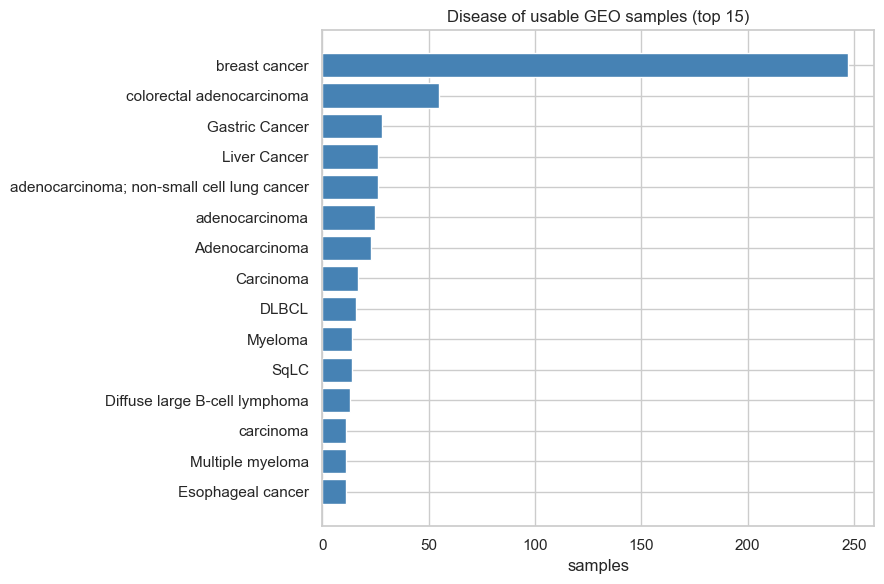

In [17]:
import __init__ as ini
d10 = pd.read_csv(ini.df10, sep="\t", usecols=["Geo_accession","Cellosaurus_ID","disease"])
gsm_in = set(sample_cols)
att = d10[d10.Geo_accession.isin(gsm_in)]
usable = att["Cellosaurus_ID"].notna().sum()
print(f"GEO sample columns in df3 : {len(gsm_in)}")
print(f"with Cellosaurus match    : {usable} ({usable/len(gsm_in)*100:.1f}% usable)")
vc = att[att.Cellosaurus_ID.notna()]["disease"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9,6))
ax.barh(vc.index[::-1], vc.values[::-1], color="steelblue")
ax.set_title("Disease of usable GEO samples (top 15)"); ax.set_xlabel("samples")
plt.tight_layout(); plt.show()

## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is **another set of "gene volume dials,"** but older and gathered from many separate public experiments through **GEO (Gene Expression Omnibus, a public archive of past lab results)**. It mostly comes from the microarray era (an older measuring technology). The values are **raw** (not squashed onto a friendly scale yet). Its main appeal is that it might cover **extra cell lines** the modern DepMap data doesn't.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **19,914 genes × 3,267 samples** (samples are labelled `GSM...`, a GEO sample code).
- It shares **99.9% of its genes** with the modern DepMap expression file — so gene-wise it lines up well.
- **But the join is very lossy: only ~18% of samples (588 of 3,267) survive** the 3-step translation to the DepMap master catalogue.
- It contributes only **~65 genuinely new cell lines** not already covered by DepMap RNA.

Next steps (preprocessing):
- **log1p-transform** the raw values (put them on the same friendly ruler as df2).
- **Align genes to the DepMap file** (df2) so they're directly comparable.
- **Decide its role**: because so little survives the join and it's a different measuring technology (risk of "batch effects" — i.e., differences caused by *how/when* it was measured, not real biology), either **keep only the ~65 new cell lines it uniquely adds**, or **drop it** as too lossy.

Still missing in EDA:
- A **batch-effect comparison against df2** on shared cell lines — do the same cell lines look the same in both files? If not, mixing them blindly would inject noise.

### 3. Which ML approach fits this dataset
**Unsupervised, supplementary feature source — likely low weight or dropped.** If kept, it's only to extend coverage to a handful of extra cell lines; it should not be a primary signal given the heavy join loss and batch-effect risk.

> **Big-picture note:** Everything still has to land on the DepMap spine (`ModelID`); a layer that loses 82% of its samples on the way there earns at most a minor, carefully-checked supporting role.